In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
from PIL import Image

In [ ]:
sample_submission = pd.read_csv("/kaggle/input/competitions/histopathologic-cancer-detection/sample_submission.csv")
train_raw = pd.read_csv("/kaggle/input/competitions/histopathologic-cancer-detection/train_labels.csv")

train_path = "/kaggle/input/competitions/histopathologic-cancer-detection/train/"
test_path = "/kaggle/input/competitions/histopathologic-cancer-detection/test/"

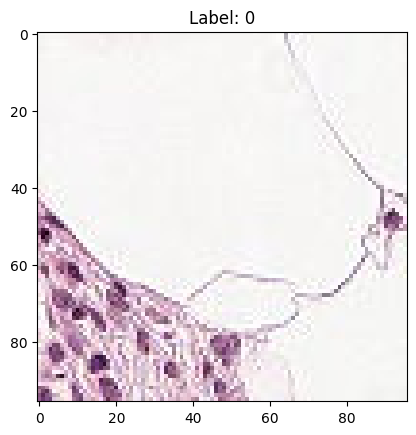

Image Size: (96, 96)


In [ ]:
# Visualization
sample_id = train_raw.iloc[0]['id']
img = Image.open(train_path + sample_id + ".tif")

plt.imshow(img)
plt.title(f"Label: {train_raw.iloc[0]['label']}")
plt.show()

print(f"Image Size: {img.size}") 

## Model Architecture

## ResNet Adapted

In [ ]:
def residual_block(x, filters, kernel_size=3):
    # Residual block 
    shortcut = x
    
    x = layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    # Skip Connection
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_resnet(input_shape=(96, 96, 3), lr=0.0001):
    # Input
    inputs = layers.Input(shape=input_shape)
    
    # First Convolution Layer
    # Extract multiresolutive features
    x = layers.Conv2D(64, (7, 7), strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)
    
    # Residual blocks
    x = residual_block(x, 64)
    x = residual_block(x, 64)
    
    # Final classificator
    # Dropout for avoid overfitting
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x) # Sigmoid for binary classification 
    
    model = models.Model(inputs, outputs)
    
    # Compilation with Adam Optimizer and Binary Crossentropy
    # NLLLoss with PyTorch implemented as BinaryCrossentropy for sigmoid output
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='roc_auc')]
    )
    
    return model

## Configuration

In [ ]:
SEED = 42
IMG_SIZE = (96, 96)
BATCH_SIZE = 32
EPOCHS = 8
AUTOTUNE = tf.data.AUTOTUNE

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [12]:
TRAIN_PATH = '/kaggle/input/competitions/histopathologic-cancer-detection/train/'
TEST_PATH  = '/kaggle/input/competitions/histopathologic-cancer-detection/test/'
LABELS_CSV = '/kaggle/input/competitions/histopathologic-cancer-detection/train_labels.csv'

In [ ]:
METRICS = [
    'accuracy',
    tf.keras.metrics.AUC(name='roc_auc', curve='ROC')
]

CB = [
    callbacks.EarlyStopping(monitor='val_roc_auc', patience=5, mode='max', restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)
]


I0000 00:00:1777991852.001606      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777991852.007534      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
def evaluate_model(model, dataset):
    probs = model.predict(dataset, verbose=0).ravel()
    labels = np.concatenate([y.numpy() for _, y in dataset], axis=0)
    preds = (probs > 0.5).astype(int)
    return {
        'accuracy': accuracy_score(labels, preds),
        'roc_auc': roc_auc_score(labels, probs)
    }

## Training 5-Fold Cross-Validation

Changes to take advantage of the 2 GPUs

In [ ]:
# For using the 2 GPUs available
strategy = tf.distribute.MirroredStrategy()
print(f'Detected Devices: {strategy.num_replicas_in_sync}') 

# Scale Batch Size
# Each GPU will process 64 images per batch giving a total of 128
BATCH_SIZE_PER_REPLICA = 64 
GLOBAL_BATCH_SIZE = BATCH_SIZE_PER_REPLICA * strategy.num_replicas_in_sync

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Detected Devices: 2


In [ ]:
# Multi-GPU Setup

# Remember that tf.data operations like map and batch will automatically distribute across the available GPUs when using MirroredStrategy.  
# Also tf.data pipeline runs in graph mode so functions must be wrapped inside another

# Choose 128 as the global batch size for multi-GPU training (64 per GPU) so both are busy at each step
def make_dataset(files, labels=None, training=False, batch_size=128):
    def decode_tiff(file_path):
        # Use of PIL as it is optimized for TIFF reading and can handle various TIFF formats more robustly than tensorflow tf.io.decode_tiff
        # Then convert to numpy for TF
        img = Image.open(file_path.numpy().decode('utf-8'))
        # Normalize to [0, 1] range for training stability
        return np.array(img).astype(np.float32) / 255.0

    def process_path(file_path, label=None):
        # localized py_function just for the decoding step
        img = tf.py_function(decode_tiff, [file_path], tf.float32)
        
        # Manually set the shape so TF can optimize the graph
        img.set_shape([96, 96, 3])
        
        if label is None:
            return img
        
        return img, label # This is to handle both labeled and unlabeled datasets as training, test sets

    # Create the base dataset from slices
    # Initializes tf.daata.Dataset yielding (file_path, label) parisonce at a time
    if labels is not None:
        ds = tf.data.Dataset.from_tensor_slices((files, labels))
    else:
        ds = tf.data.Dataset.from_tensor_slices(files)
    
    # Applies process_path function to every item in the dataset
    # Using AUTOTUNE to run multiple decoders in parallel in CPU to avoid GPU bottleneck
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    
    if training:
        # Shuffling randomizes the order during training
        # Shuffling and repeating ensures the multi-GPU pipeline stays full
        # Shuffling is essential to mitigate bias and prevent overfitting
        ds = ds.shuffle(2048)
    
    # Global Batch Size (128) distributed across 2 GPUs
    # Prefetch reduces CPU loading times for next step
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
# Multi-GPU Setup 

# Adjust batch size for multi-GPU: each GPU gets its own portion of the batch
# BATCH_SIZE_PER_REPLICA = 64 
# GLOBAL_BATCH_SIZE = BATCH_SIZE_PER_REPLICA * strategy.num_replicas_in_sync

# Training Configuration 
K_FOLDS = 5 # Number of folds
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
# This sklearn tool provides cross-validation tool that maintains the percentage of samples for each class
# This solves our problem for imbalanced datasets and ensures each fold is representative of the overall distribution

# Storage for the resulting metrics for each validation 
all_fold_results = []

labels_df    = pd.read_csv(LABELS_CSV)
train_files  = np.array([os.path.join(TRAIN_PATH, f"{x}.tif") for x in labels_df.id])
train_labels = labels_df.label.values
 
skf             = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
all_fold_results = []
 
for fold, (train_idx, val_idx) in enumerate(skf.split(train_files, train_labels)):
    print(f"\n── Fold {fold + 1} / {K_FOLDS} ──")
 
    train_ds = make_dataset(
        train_files[train_idx], train_labels[train_idx],
        training=True, batch_size=GLOBAL_BATCH_SIZE
    )
    val_ds = make_dataset(
        train_files[val_idx], train_labels[val_idx],
        batch_size=GLOBAL_BATCH_SIZE
    )
 
    # Build, Train, and Evaluate
    # We build the model within the strategy scope to replicate it on both GPUs
    with strategy.scope():
        # We Re-build the model each time to start fresh and prevent data leakage, new weights each fold
        # This allow the cross validation to better performance analysis
        model = build_resnet() 
        
        # Compile inside the scope to ensure optimizer variables are correctly distributed
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='roc_auc')]
        )
    
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=8,
        callbacks=CB,
        verbose=1
    )
    
    # Collect Metrics for this fold
    metrics = evaluate_model(model, val_ds)
    all_fold_results.append(metrics)
    print(f"Fold {fold+1} Accuracy: {metrics['accuracy']:.4f}")

    # Save the model for future testing
    # Saving in .keras format for native Keras 3 support and clinical portability
    model.save(f"/kaggle/working/res_net_3_fold{fold+1}.keras")
    print(f"Model of {fold+1} saved")

# Final averaging to provide a reliable measure of the model generalization 
# We average the different accuracies obtained in each fold
mean_accuracy = np.mean([m['accuracy'] for m in all_fold_results])
print(f"\nFinal K-Fold Mean Accuracy: {mean_accuracy:.4f}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2

 EXECUTING FOLD 1 / 5 (DISTRIBUTED MODE)
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to

I0000 00:00:1777991877.946386      74 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777991877.946440      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


1376/1376 ━━━━━━━━━━━━━━━━━━━━ 611s 434ms/step - accuracy: 0.7944 - loss: 0.4572 - roc_auc: 0.8619 - val_accuracy: 0.8547 - val_loss: 0.3649 - val_roc_auc: 0.9305 - learning_rate: 1.0000e-04
Epoch 2/8
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 427s 308ms/step - accuracy: 0.8505 - loss: 0.3493 - roc_auc: 0.9210 - val_accuracy: 0.7281 - val_loss: 0.9188 - val_roc_auc: 0.7424 - learning_rate: 1.0000e-04
Epoch 3/8
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 419s 302ms/step - accuracy: 0.8726 - loss: 0.3046 - roc_auc: 0.9402 - val_accuracy: 0.7475 - val_loss: 0.6693 - val_roc_auc: 0.8416 - learning_rate: 1.0000e-04
Epoch 4/8
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 425s 306ms/step - accuracy: 0.8903 - loss: 0.2684 - roc_auc: 0.9538 - val_accuracy: 0.8089 - val_loss: 0.5619 - val_roc_auc: 0.8838 - learning_rate: 2.0000e-05
Epoch 5/8
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 420s 303ms/step - accuracy: 0.8947 - loss: 0.2595 - roc_auc: 0.9568 - val_accuracy: 0.8769 - val_loss: 0.2821 - val_roc_auc: 0.9613 - learning_rate: 2.0000e-05
Epoch